In [1]:
# Imports and Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from scipy.spatial.distance import pdist, squareform
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')
import os

# Set style
plt.style.use('seaborn-v0_8-paper')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['font.size'] = 10

# random seed
np.random.seed(42)

In [ ]:
print(f"Current working directory: {os.getcwd()}")

# os.chdir(Path(os.getcwd()).parent)
# print(f"New working directory: {os.getcwd()}")


Current working directory: /home/sjoon/projects/brain_connectivity_classifier/Notebooks
New working directory: /home/sjoon/projects/brain_connectivity_classifier


In [4]:
# Load Data
PIOP2_PATH = "data/raw/PIOP2_restingstate.csv"
PIOP1_PATH = "data/raw/PIOP1_gstroop.csv"

# Load datasets
df_rest = pd.read_csv(PIOP2_PATH)
df_task = pd.read_csv(PIOP1_PATH)

print(f"PIOP2 (Rest) shape: {df_rest.shape}")
print(f"PIOP1 (Task) shape: {df_task.shape}")
print(f"\nFirst few columns: {list(df_rest.columns[:5])}")

PIOP2 (Rest) shape: (224, 26797)
PIOP1 (Task) shape: (200, 26797)

First few columns: ['subject', 'LH_VisCent_ExStr_2~LH_VisCent_ExStr_1', 'LH_VisCent_Striate_1~LH_VisCent_ExStr_1', 'LH_VisCent_Striate_1~LH_VisCent_ExStr_2', 'LH_VisCent_ExStr_3~LH_VisCent_ExStr_1']


In [5]:
# Extract subject IDs and connection data
subject_col = df_rest.columns[0]
connection_cols = [col for col in df_rest.columns if '~' in str(col)]

print(f"Subject ID column: {subject_col}")
print(f"Number of connection columns: {len(connection_cols)}")
print(f"Sample connection columns: {connection_cols[:3]}")

# Extract connectivity matrices
X_rest = df_rest[connection_cols].values
X_task = df_task[connection_cols].values

print(f"\nX_rest shape: {X_rest.shape}")
print(f"X_task shape: {X_task.shape}")

Subject ID column: subject
Number of connection columns: 26796
Sample connection columns: ['LH_VisCent_ExStr_2~LH_VisCent_ExStr_1', 'LH_VisCent_Striate_1~LH_VisCent_ExStr_1', 'LH_VisCent_Striate_1~LH_VisCent_ExStr_2']

X_rest shape: (224, 26796)
X_task shape: (200, 26796)


#### SECTION 1: DATA QUALITY & STRUCTURE


In [6]:
# Basic Data Quality Checks
# Sample sizes
print(f"\n1.1 Sample Sizes:")
print(f"  PIOP2 (Rest): {len(df_rest)} subjects")
print(f"  PIOP1 (Task): {len(df_task)} subjects")
print(f"  Features: {len(connection_cols)} connections")

# Missing data
print(f"\n1.2 Missing Data:")
print(f"  PIOP2 missing: {df_rest[connection_cols].isnull().sum().sum()}")
print(f"  PIOP1 missing: {df_task[connection_cols].isnull().sum().sum()}")

# Value ranges
print(f"\n1.3 Value Ranges (correlation values should be [-1, 1]):")
print(f"  PIOP2 range: [{X_rest.min():.4f}, {X_rest.max():.4f}]")
print(f"  PIOP1 range: [{X_task.min():.4f}, {X_task.max():.4f}]")

# Check for values outside valid range
rest_invalid = ((X_rest < -1) | (X_rest > 1)).sum()
task_invalid = ((X_task < -1) | (X_task > 1)).sum()
print(f"  PIOP2 invalid values: {rest_invalid}")
print(f"  PIOP1 invalid values: {task_invalid}")

# Subject ID overlap check
rest_subjects = set(df_rest[subject_col].values)
task_subjects = set(df_task[subject_col].values)
overlap = rest_subjects.intersection(task_subjects)
print(f"\n1.4 Subject Overlap in Rest and Task datasets:")
print(f"  Overlapping subjects: {len(overlap)}")
if len(overlap) > 0:
    print(f" Found {len(overlap)} subjects in both datasets!")


1.1 Sample Sizes:
  PIOP2 (Rest): 224 subjects
  PIOP1 (Task): 200 subjects
  Features: 26796 connections

1.2 Missing Data:
  PIOP2 missing: 0
  PIOP1 missing: 0

1.3 Value Ranges (correlation values should be [-1, 1]):
  PIOP2 range: [-0.8850, 0.9674]
  PIOP1 range: [-0.8708, 0.9634]
  PIOP2 invalid values: 0
  PIOP1 invalid values: 0

1.4 Subject Overlap in Rest and Task datasets:
  Overlapping subjects: 0


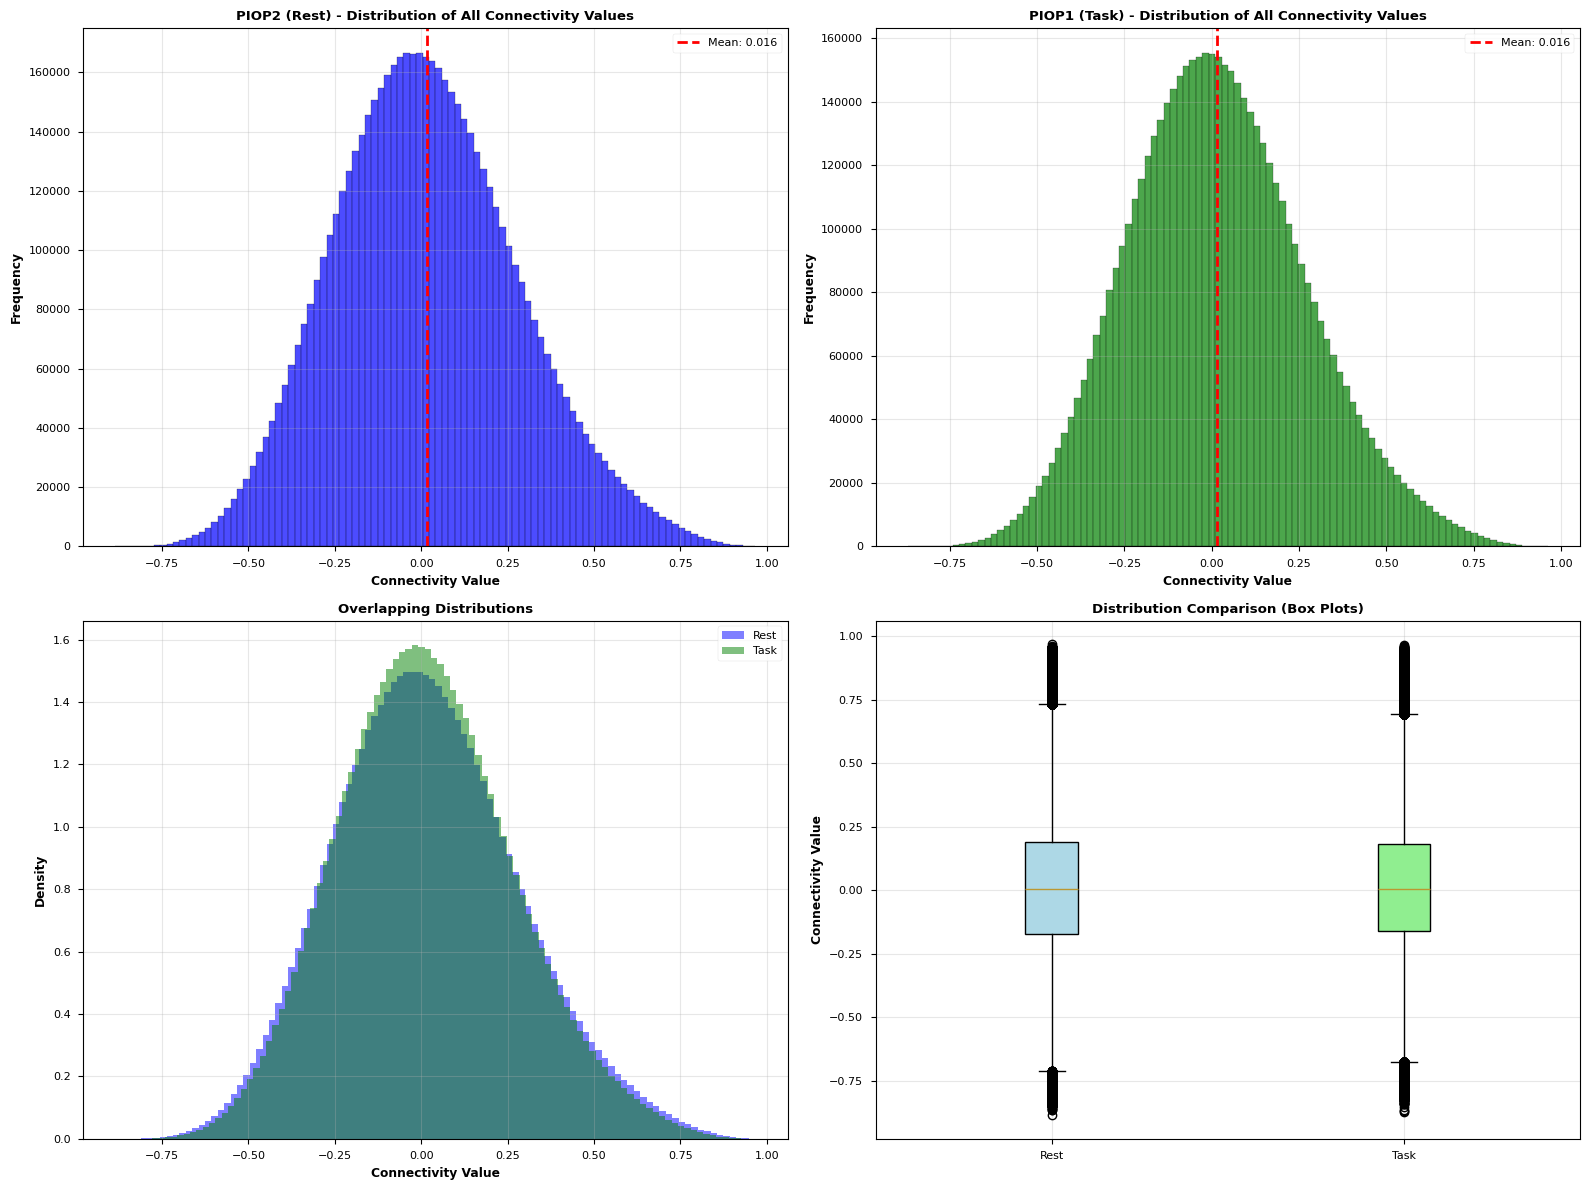

In [7]:
# Distribution of Connectivity Values
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Histogram - Rest
axes[0, 0].hist(X_rest.flatten(), bins=100, alpha=0.7, color='blue', edgecolor='black')
axes[0, 0].set_xlabel('Connectivity Value', fontweight='bold')
axes[0, 0].set_ylabel('Frequency', fontweight='bold')
axes[0, 0].set_title('PIOP2 (Rest) - Distribution of All Connectivity Values', fontweight='bold')
axes[0, 0].axvline(X_rest.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {X_rest.mean():.3f}')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Histogram - Task
axes[0, 1].hist(X_task.flatten(), bins=100, alpha=0.7, color='green', edgecolor='black')
axes[0, 1].set_xlabel('Connectivity Value', fontweight='bold')
axes[0, 1].set_ylabel('Frequency', fontweight='bold')
axes[0, 1].set_title('PIOP1 (Task) - Distribution of All Connectivity Values', fontweight='bold')
axes[0, 1].axvline(X_task.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {X_task.mean():.3f}')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Overlapping KDE
axes[1, 0].hist(X_rest.flatten(), bins=100, alpha=0.5, color='blue', label='Rest', density=True)
axes[1, 0].hist(X_task.flatten(), bins=100, alpha=0.5, color='green', label='Task', density=True)
axes[1, 0].set_xlabel('Connectivity Value', fontweight='bold')
axes[1, 0].set_ylabel('Density', fontweight='bold')
axes[1, 0].set_title('Overlapping Distributions', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Box plots
box_data = [X_rest.flatten(), X_task.flatten()]
bp = axes[1, 1].boxplot(box_data, labels=['Rest', 'Task'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightgreen')
axes[1, 1].set_ylabel('Connectivity Value', fontweight='bold')
axes[1, 1].set_title('Distribution Comparison (Box Plots)', fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

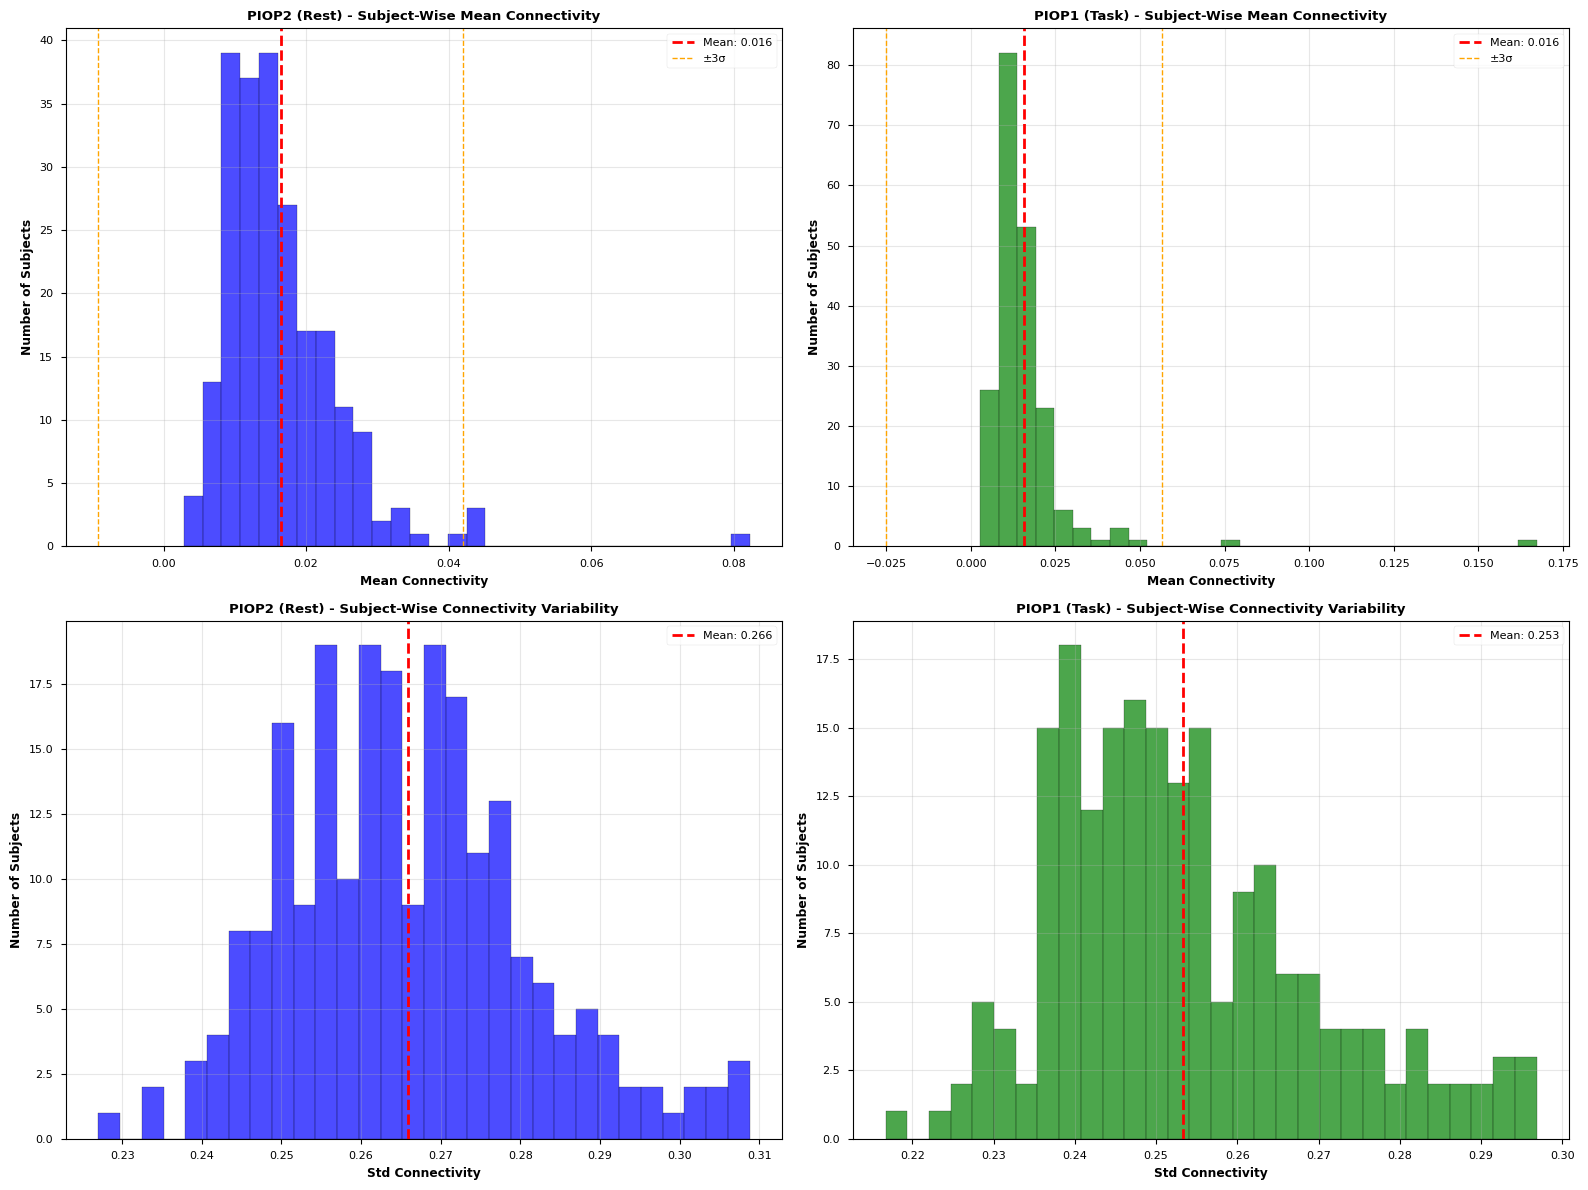


Outlier Detection (3σ threshold):
  Rest outliers: 4 subjects
  Task outliers: 2 subjects


In [8]:
# Check for Outlier Subjects
# Calculate mean connectivity per subject
rest_subject_means = X_rest.mean(axis=1)
task_subject_means = X_task.mean(axis=1)

# Calculate std connectivity per subject
rest_subject_stds = X_rest.std(axis=1)
task_subject_stds = X_task.std(axis=1)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Mean connectivity per subject - Rest
axes[0, 0].hist(rest_subject_means, bins=30, alpha=0.7, color='blue', edgecolor='black')
axes[0, 0].axvline(rest_subject_means.mean(), color='red', linestyle='--', linewidth=2, 
                   label=f'Mean: {rest_subject_means.mean():.3f}')
axes[0, 0].axvline(rest_subject_means.mean() - 3*rest_subject_means.std(), 
                   color='orange', linestyle='--', linewidth=1, label='±3σ')
axes[0, 0].axvline(rest_subject_means.mean() + 3*rest_subject_means.std(), 
                   color='orange', linestyle='--', linewidth=1)
axes[0, 0].set_xlabel('Mean Connectivity', fontweight='bold')
axes[0, 0].set_ylabel('Number of Subjects', fontweight='bold')
axes[0, 0].set_title('PIOP2 (Rest) - Subject-Wise Mean Connectivity', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Mean connectivity per subject - Task
axes[0, 1].hist(task_subject_means, bins=30, alpha=0.7, color='green', edgecolor='black')
axes[0, 1].axvline(task_subject_means.mean(), color='red', linestyle='--', linewidth=2,
                   label=f'Mean: {task_subject_means.mean():.3f}')
axes[0, 1].axvline(task_subject_means.mean() - 3*task_subject_means.std(), 
                   color='orange', linestyle='--', linewidth=1, label='±3σ')
axes[0, 1].axvline(task_subject_means.mean() + 3*task_subject_means.std(), 
                   color='orange', linestyle='--', linewidth=1)
axes[0, 1].set_xlabel('Mean Connectivity', fontweight='bold')
axes[0, 1].set_ylabel('Number of Subjects', fontweight='bold')
axes[0, 1].set_title('PIOP1 (Task) - Subject-Wise Mean Connectivity', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Std connectivity per subject - Rest
axes[1, 0].hist(rest_subject_stds, bins=30, alpha=0.7, color='blue', edgecolor='black')
axes[1, 0].axvline(rest_subject_stds.mean(), color='red', linestyle='--', linewidth=2,
                   label=f'Mean: {rest_subject_stds.mean():.3f}')
axes[1, 0].set_xlabel('Std Connectivity', fontweight='bold')
axes[1, 0].set_ylabel('Number of Subjects', fontweight='bold')
axes[1, 0].set_title('PIOP2 (Rest) - Subject-Wise Connectivity Variability', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Std connectivity per subject - Task
axes[1, 1].hist(task_subject_stds, bins=30, alpha=0.7, color='green', edgecolor='black')
axes[1, 1].axvline(task_subject_stds.mean(), color='red', linestyle='--', linewidth=2,
                   label=f'Mean: {task_subject_stds.mean():.3f}')
axes[1, 1].set_xlabel('Std Connectivity', fontweight='bold')
axes[1, 1].set_ylabel('Number of Subjects', fontweight='bold')
axes[1, 1].set_title('PIOP1 (Task) - Subject-Wise Connectivity Variability', fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Identify outliers (beyond 3 standard deviations)
rest_outliers = np.abs(rest_subject_means - rest_subject_means.mean()) > 3 * rest_subject_means.std()
task_outliers = np.abs(task_subject_means - task_subject_means.mean()) > 3 * task_subject_means.std()

print(f"\nOutlier Detection (3σ threshold):")
print(f"  Rest outliers: {rest_outliers.sum()} subjects")
print(f"  Task outliers: {task_outliers.sum()} subjects")

1. Subject-level mean functional connectivity converges near zero for both Rest (≈0.016) and Task (≈0.016), consistent with the expectation that whole-brain correlation matrices balance weak positive and negative interactions at the global scale.

2. Between-subject dispersion in mean connectivity is minimal, reflecting a highly conserved global connectivity baseline across individuals in both cognitive states.

3. Connectivity variability (subject-wise standard deviation across all edges) is markedly higher than global mean connectivity, with group averages of ≈0.266 (Rest) and ≈0.253 (Task), indicating substantial heterogeneity in edgewise correlation strengths within each subject.

4. Variability distributions are broader and more symmetric than those of mean connectivity, suggesting that inter-individual differences are expressed more strongly through the heterogeneity of network organization rather than shifts in overall correlation magnitude.

5. Resting-state data show slightly elevated variability relative to task, consistent with the notion that unconstrained intrinsic activity exhibits greater functional diversity than task-evoked connectivity patterns, which tend to be more structured and state-specific.


In [9]:
# Statistical Comparison of Distributions
print("CONNECTIVITY DISTRIBUTION - REST VS TASK")

# Flatten arrays for comparison
rest_flat = X_rest.flatten()
task_flat = X_task.flatten()

# Descriptive statistics
print("\n2.1 Descriptive Statistics:")
print(f"  Rest - Mean: {rest_flat.mean():.4f}, Std: {rest_flat.std():.4f}")
print(f"  Task - Mean: {task_flat.mean():.4f}, Std: {task_flat.std():.4f}")
print(f"  Difference: {task_flat.mean() - rest_flat.mean():.4f}")

# Two-sample t-test
t_stat, t_pval = stats.ttest_ind(rest_flat, task_flat)
print(f"\n2.2 Two-Sample T-Test:")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {t_pval:.4e}")
if t_pval < 0.05:
    print(f"  ✓ Significant difference (p < 0.05)")
else:
    print(f"  ✗ No significant difference (p ≥ 0.05)")

# Mann-Whitney U test (non-parametric)
u_stat, u_pval = stats.mannwhitneyu(rest_flat, task_flat, alternative='two-sided')
print(f"\n2.3 Mann-Whitney U Test:")
print(f"  U-statistic: {u_stat:.4e}")
print(f"  p-value: {u_pval:.4e}")
if u_pval < 0.05:
    print(f"  ✓ Significant difference (p < 0.05)")
else:
    print(f"  ✗ No significant difference (p ≥ 0.05)")

# Kolmogorov-Smirnov test
ks_stat, ks_pval = stats.ks_2samp(rest_flat, task_flat)
print(f"\n2.4 Kolmogorov-Smirnov Test:")
print(f"  KS-statistic: {ks_stat:.4f}")
print(f"  p-value: {ks_pval:.4e}")
if ks_pval < 0.05:
    print(f"  ✓ Distributions differ significantly (p < 0.05)")
else:
    print(f"  ✗ Distributions do not differ (p ≥ 0.05)")

# Effect size (Cohen's d)
pooled_std = np.sqrt((rest_flat.std()**2 + task_flat.std()**2) / 2)
cohens_d = (task_flat.mean() - rest_flat.mean()) / pooled_std
print(f"\n2.5 Effect Size (Cohen's d): {cohens_d:.4f}")
if abs(cohens_d) < 0.2:
    print(f"  → Negligible effect")
elif abs(cohens_d) < 0.5:
    print(f"  → Small effect")
elif abs(cohens_d) < 0.8:
    print(f"  → Medium effect")
else:
    print(f"  → Large effect")

CONNECTIVITY DISTRIBUTION - REST VS TASK

2.1 Descriptive Statistics:
  Rest - Mean: 0.0165, Std: 0.2664
  Task - Mean: 0.0157, Std: 0.2541
  Difference: -0.0008

2.2 Two-Sample T-Test:
  t-statistic: 4.8940
  p-value: 9.8785e-07
  ✓ Significant difference (p < 0.05)

2.3 Mann-Whitney U Test:
  U-statistic: 1.6072e+13
  p-value: 2.9513e-02
  ✓ Significant difference (p < 0.05)

2.4 Kolmogorov-Smirnov Test:
  KS-statistic: 0.0129
  p-value: 0.0000e+00
  ✓ Distributions differ significantly (p < 0.05)

2.5 Effect Size (Cohen's d): -0.0029
  → Negligible effect


1. Two-sample t-test → tests difference in means assuming normality.
You need it to check if average connectivity differs.

2. Mann–Whitney U test → tests difference in ranks/medians, no assumptions.
You need it because connectivity data are not perfectly normal.

3. KS test → compares entire distribution shapes.
You need it to confirm whether rest and task distributions differ in any way.

4. Cohen’s d → measures effect size (practical importance).
You need it because significance ≠ meaningful difference.

Your case shows: Statistically significant, but Practically negligible difference in connectivity.

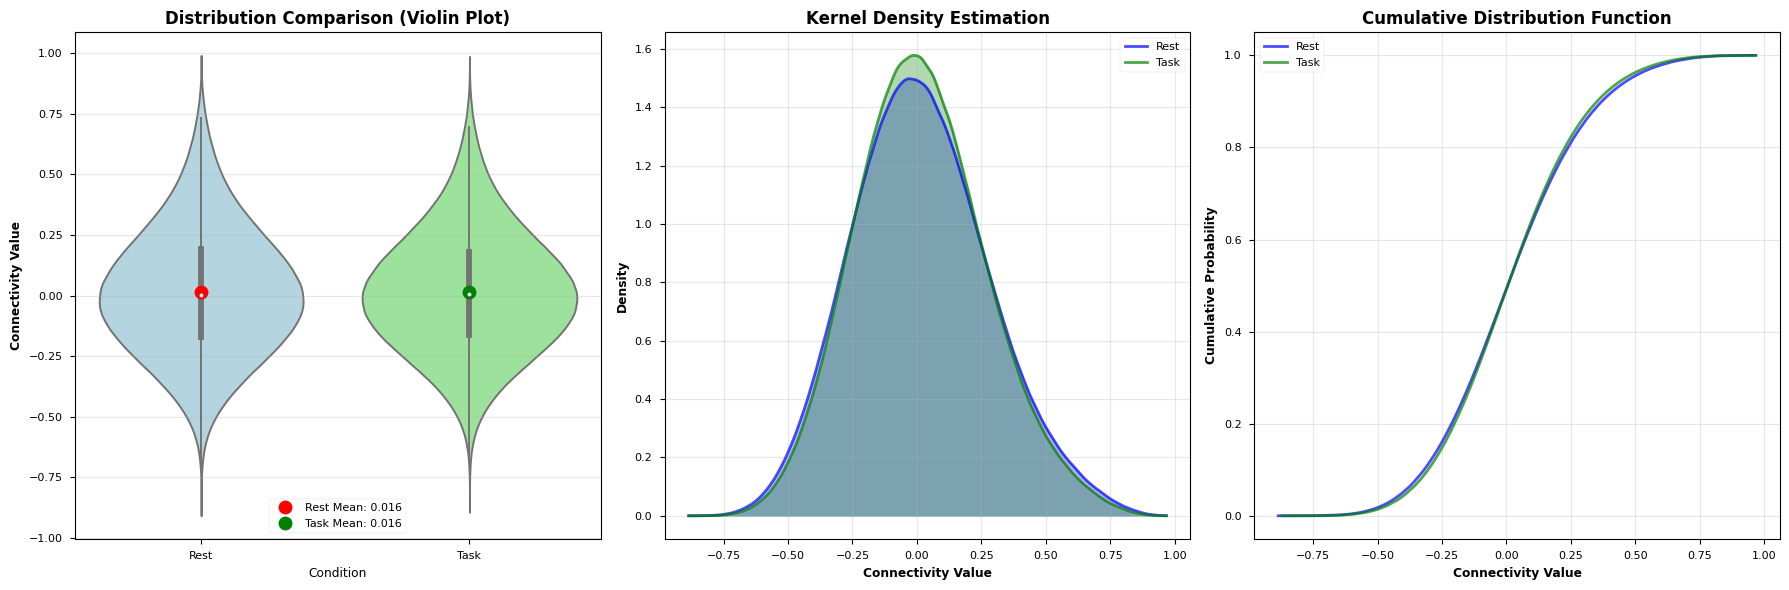

In [10]:
# Violin Plots and KDE Comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Violin plot
violin_data = pd.DataFrame({
    'Connectivity': np.concatenate([rest_flat, task_flat]),
    'Condition': ['Rest']*len(rest_flat) + ['Task']*len(task_flat)
})

sns.violinplot(data=violin_data, x='Condition', y='Connectivity', ax=axes[0], 
               palette={'Rest': 'lightblue', 'Task': 'lightgreen'})
axes[0].set_title('Distribution Comparison (Violin Plot)', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Connectivity Value', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Add mean markers
rest_mean = rest_flat.mean()
task_mean = task_flat.mean()
axes[0].plot(0, rest_mean, 'ro', markersize=10, label=f'Rest Mean: {rest_mean:.3f}')
axes[0].plot(1, task_mean, 'go', markersize=10, label=f'Task Mean: {task_mean:.3f}')
axes[0].legend()

# KDE plot
from scipy.stats import gaussian_kde

rest_kde = gaussian_kde(rest_flat)
task_kde = gaussian_kde(task_flat)

x_range = np.linspace(min(rest_flat.min(), task_flat.min()), 
                      max(rest_flat.max(), task_flat.max()), 1000)

axes[1].plot(x_range, rest_kde(x_range), 'b-', linewidth=2, label='Rest', alpha=0.7)
axes[1].plot(x_range, task_kde(x_range), 'g-', linewidth=2, label='Task', alpha=0.7)
axes[1].fill_between(x_range, rest_kde(x_range), alpha=0.3, color='blue')
axes[1].fill_between(x_range, task_kde(x_range), alpha=0.3, color='green')
axes[1].set_xlabel('Connectivity Value', fontweight='bold')
axes[1].set_ylabel('Density', fontweight='bold')
axes[1].set_title('Kernel Density Estimation', fontweight='bold', fontsize=12)
axes[1].legend()
axes[1].grid(alpha=0.3)

# Cumulative distribution
rest_sorted = np.sort(rest_flat)
task_sorted = np.sort(task_flat)
rest_cumulative = np.arange(1, len(rest_sorted)+1) / len(rest_sorted)
task_cumulative = np.arange(1, len(task_sorted)+1) / len(task_sorted)

axes[2].plot(rest_sorted, rest_cumulative, 'b-', linewidth=2, label='Rest', alpha=0.7)
axes[2].plot(task_sorted, task_cumulative, 'g-', linewidth=2, label='Task', alpha=0.7)
axes[2].set_xlabel('Connectivity Value', fontweight='bold')
axes[2].set_ylabel('Cumulative Probability', fontweight='bold')
axes[2].set_title('Cumulative Distribution Function', fontweight='bold', fontsize=12)
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

1. Rest and task show highly similar connectivity distributions, with both centered near zero.
2. Mean connectivity values are same (rest ≈ 0.016, task ≈ 0.016).
3.The task distribution is slightly narrower, suggesting marginally lower variability.
4. Density and CDF curves largely overlap, indicating no major shift between conditions.
5. Overall, the results show comparable global connectivity patterns during rest and task.